In [20]:
import torch 
max_len = 10000
d_model = 600
import math
positions = torch.arange(max_len ).unsqueeze(1).float()
freq = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
res = positions*freq
pe = torch.zeros(max_len, d_model)
pe[:, 0::2] = torch.sin(res)   # even indices: 0, 2, 4, ...
pe[:, 1::2] = torch.cos(res)   


In [23]:
# lets maek thsi a module 
import torch.nn as nn 
class SinusoidalPE(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        positions = torch.arange(max_len ).unsqueeze(1).float()
        freq = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        res = positions*freq
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(res)   # even indices: 0, 2, 4, ...
        pe[:, 1::2] = torch.cos(res)   
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]
    

In [24]:
from matplotlib import pyplot as plt 


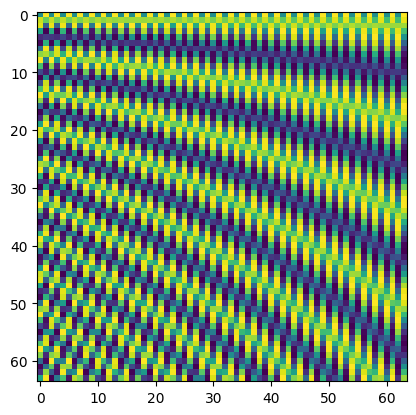

In [26]:
plt.imshow(pe[:64, :64])

In [ ]:
# rope implementations 
import torch.nn as nn 
class ROPE(nn.Module):
    def __init__(self, dim, max_len, theta=10000):
        super().__init__()
        freq = torch.exp(torch.arange(0, dim, 2).float() * -(math.log(theta) / dim))
        positions = torch.arange(max_len).float()
        angles = torch.outer(positions, freq)
        self.register_buffer("angles", angles)

    def forward(self, x):
        seq_len = x.size(1)
        cos = torch.cos(self.angles[:seq_len]).unsqueeze(0)
        sin = torch.sin(self.angles[:seq_len]).unsqueeze(0)
        x1 = x[..., :x.size(-1)//2]
        x2 = x[..., x.size(-1)//2:]
        out1 = x1*cos - x2*sin
        out2 = x1*sin + x2*cos
        return torch.cat([out1, out2], dim=-1)

## Concept Check — Q&A

**Q1: Why rotation instead of addition?**

Addition: `(q + pe_m) · (k + pe_n)` expands into cross terms that mix content with absolute position.
The model must *learn* to extract relative position from this mess.

Rotation: `R(mθ)q · R(nθ)k = q · R((n-m)θ)k` — only the relative distance (m-n) remains, by construction.
No learning needed to get relative position — it's baked into the geometry.

**Q2: dim=8, position=3. How many rotations? What determines the angle?**

4 rotations (dim/2 pairs). Each pair `i` is rotated by `position * θ_i` = `3 * θ_i`.
- Pair 0: fast rotation (high freq)
- Pair 3: slow rotation (low freq)
- θ_i = 1/10000^(2i/dim) — same geometric spacing as sinusoidal.

**Q3: Same relative distance → same dot product?**

Yes. dot(q@10, k@7) == dot(q@100, k@97) if raw vectors are the same.
Only the difference in positions matters, not the absolute positions.

**Q4: RoPE has no trainable params. Where does learning happen?**

In W_Q and W_K (the projection matrices). The model learns to project tokens into
directions that, *after* rotation, produce high dot products at the relative distances
it cares about. RoPE provides the coordinate system; W_Q/W_K learn to navigate it.

---

## Summary Table

| Method | Params | Relative pos? | Extrapolation | Used in |
|--------|--------|--------------|---------------|---------|
| Sinusoidal | 0 | Implicit (linear transform) | Moderate | Original Transformer |
| Learned | max_len × d | No | Poor (OOD) | BERT, GPT-2 |
| RoPE | 0 | Yes (dot product) | Good | Llama, Mistral, Gemma |